# LINMA2471 - Optimization Models and Methods II
## Project: Markowitz Portfolio Optimization

---

<p></p>

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Force reload of modules (important après modification des fichiers .py)
import importlib
import models
import methods
import data
importlib.reload(models)
importlib.reload(methods)
importlib.reload(data)

from models import *
from methods import *
from data import *

### Load data

In [2]:
processor = DataProcessor()
data = processor.get_optimization_data()

### Load model

In [3]:
# Create Smooth Model instance
model = SmoothMarkowitzModel({
    "mu": data['mu'],
    "sigma": data['sigma'],
    "lam": 0.5
})


### Projected GD

In [4]:

# Compute Lipschitz constant for step size
L = model.lipschitz_constant()

# Create optimization method instance
method = ProjectedGradientMethod({
    'step_size': 1.0 / L,
    'max_iter': 1000,
    'tol': 1e-6,
}, IteratePerformanceIndicator())

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0])

# Optimize portfolio on training data
result_ProjectedGradientMethod = method.optimize(model, w0)

print("Keys disponibles:", result_ProjectedGradientMethod.keys())
print(f"Converged: {result_ProjectedGradientMethod['converged']}")
print(f"Iterations: {result_ProjectedGradientMethod['iterations']}")
#Plot valeur objectif en fonction des iterations





Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: True
Iterations: 618


#### Analyse convergence Projected gradient descent

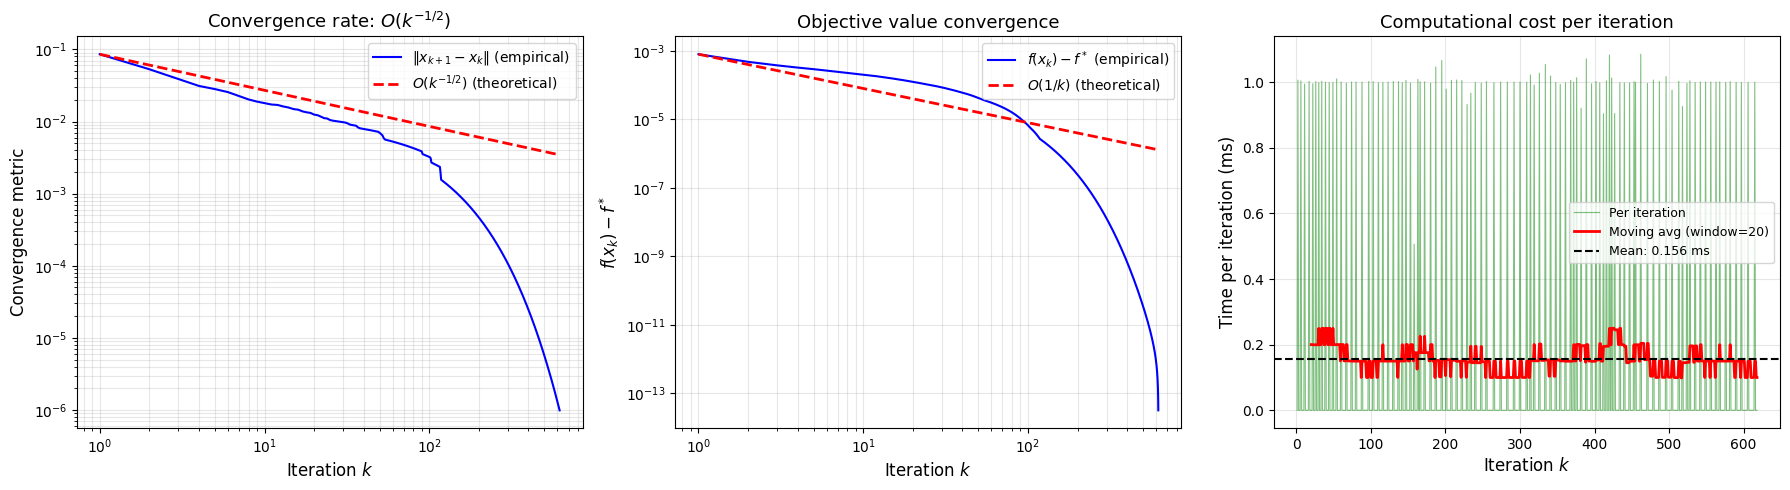

Total time: 0.0965 seconds
Total iterations: 618
Final objective value: -0.001049
Average time per iteration: 0.1562 ms
Std time per iteration: 0.3627 ms


In [14]:
# Plot convergence in iteration 
def plot_convergence(result, theoretical_rate_exp=-0.5, rate_label=r'$O(k^{-1/2})$'):
    """
    Plot convergence analysis.
    
    Args:
        result: dict with 'metric', 'time', 'obj_value' keys
        theoretical_rate_exp: exponent for theoretical rate (e.g., -0.5 for O(k^{-1/2}), -1 for O(1/k))
        rate_label: label for the theoretical rate in the legend
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    iterations = np.arange(1, len(result['metric']) + 1, dtype=float)
    metric = np.array(result['metric'])
    obj_values = np.array(result['obj_value'])
    time_values = np.array(result['time'])
    
    # Compute time per iteration (difference between consecutive cumulative times)
    time_per_iter = np.diff(np.concatenate([[0], time_values])) * 1000  # Convert to ms

    # Plot 1: Convergence metric vs iterations with theoretical rate
    ax1 = axes[0]
    ax1.loglog(iterations, metric, 'b-', linewidth=1.5, label=r'$\|x_{k+1} - x_k\|$ (empirical)')

    # Theoretical rate: fit constant to match initial value
    C = metric[0]
    theoretical_rate = C * (iterations ** theoretical_rate_exp)
    ax1.loglog(iterations, theoretical_rate, 'r--', linewidth=2, label=f'{rate_label} (theoretical)')

    ax1.set_xlabel('Iteration $k$', fontsize=12)
    ax1.set_ylabel('Convergence metric', fontsize=12)
    ax1.set_title(f'Convergence rate: {rate_label}', fontsize=13)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3, which='both')

    # Plot 2: Objective value convergence f(x_k) - f*
    ax2 = axes[1]
    f_star = obj_values[-1]  # Approximate f* with final value
    obj_gap = obj_values[:-1] - f_star  # Remove last element (it's 0)
    iterations_obj = np.arange(1, len(obj_gap) + 1, dtype=float)
    
    ax2.loglog(iterations_obj, obj_gap, 'b-', linewidth=1.5, label=r'$f(x_k) - f^*$ (empirical)')
    
    # Theoretical rate for objective: O(1/k) for convex functions
    C_obj = obj_gap[0]
    theoretical_obj = C_obj / iterations_obj
    ax2.loglog(iterations_obj, theoretical_obj, 'r--', linewidth=2, label=r'$O(1/k)$ (theoretical)')
    
    ax2.set_xlabel('Iteration $k$', fontsize=12)
    ax2.set_ylabel(r'$f(x_k) - f^*$', fontsize=12)
    ax2.set_title('Objective value convergence', fontsize=13)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, which='both')

    # Plot 3: Time per iteration
    ax3 = axes[2]
    ax3.plot(iterations, time_per_iter, 'g-', linewidth=0.8, alpha=0.5, label='Per iteration')
    # Add moving average for smoothing
    window = min(20, len(time_per_iter) // 5) if len(time_per_iter) > 5 else 1
    if window > 1:
        moving_avg = np.convolve(time_per_iter, np.ones(window)/window, mode='valid')
        ax3.plot(iterations[window-1:], moving_avg, 'r-', linewidth=2, label=f'Moving avg (window={window})')
    ax3.axhline(y=np.mean(time_per_iter), color='k', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(time_per_iter):.3f} ms')
    ax3.set_xlabel('Iteration $k$', fontsize=12)
    ax3.set_ylabel('Time per iteration (ms)', fontsize=12)
    ax3.set_title('Computational cost per iteration', fontsize=13)
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Summary stats
    print(f"Total time: {result['time'][-1]:.4f} seconds")
    print(f"Total iterations: {len(result['metric'])}")
    print(f"Final objective value: {obj_values[-1]:.6f}")
    print(f"Average time per iteration: {np.mean(time_per_iter):.4f} ms")
    print(f"Std time per iteration: {np.std(time_per_iter):.4f} ms")

plot_convergence(result_ProjectedGradientMethod, theoretical_rate_exp=-0.5, rate_label=r'$O(k^{-1/2})$')

### Projected gradient with momentum

In [15]:

L = model.lipschitz_constant()

# Create optimization method instance
method = ProjectedGradientDescentMomentum({
    'step_size': 1.0 / L,
    'max_iter': 1000,
    'tol': 1e-6,
    'momentum':0.9,
}, IteratePerformanceIndicator())

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0])

# Optimize portfolio on training data
result_ProjectedGradientDescentMomentum = method.optimize(model, w0)

print("Keys disponibles:", result_ProjectedGradientDescentMomentum.keys())
print(f"Converged: {result_ProjectedGradientDescentMomentum['converged']}")
print(f"Iterations: {result_ProjectedGradientDescentMomentum['iterations']}")
#Plot valeur objectif en fonction des iterations





Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: True
Iterations: 144


#### Analyse convergence Projected gradient with momentum

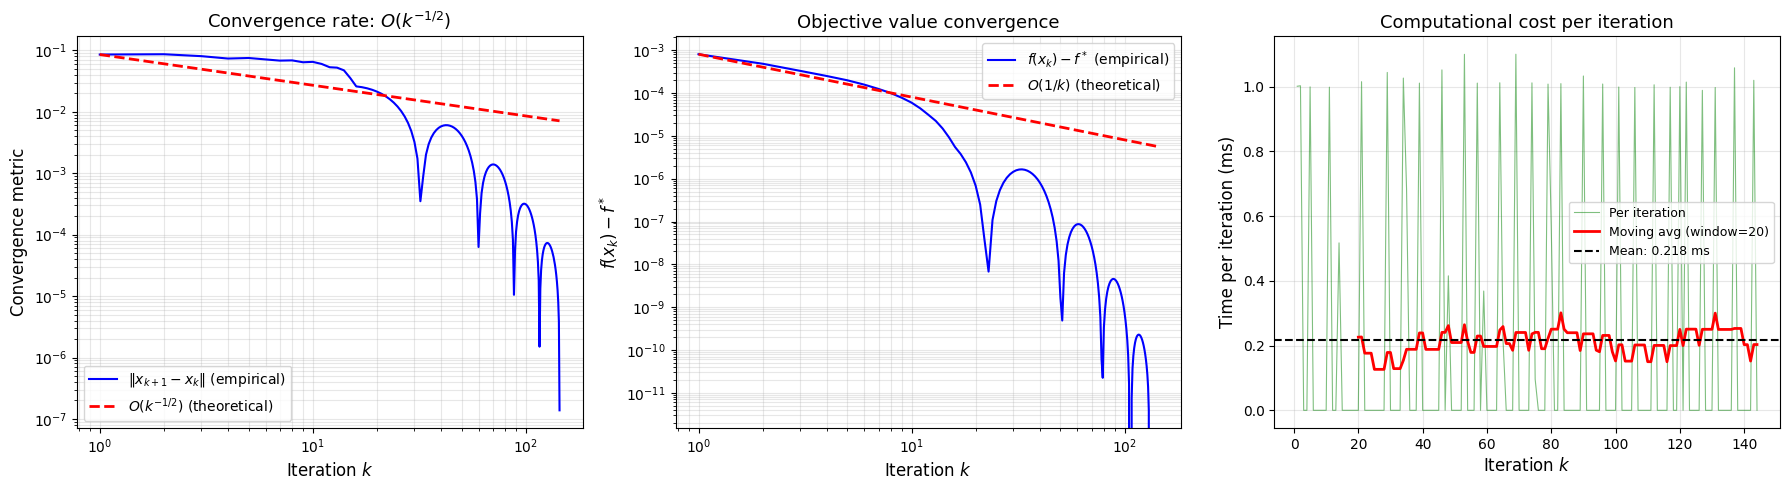

Total time: 0.0314 seconds
Total iterations: 144
Final objective value: -0.001049
Average time per iteration: 0.2180 ms
Std time per iteration: 0.4054 ms


In [16]:
plot_convergence(result_ProjectedGradientDescentMomentum)

#### Projected Randomized Coordinate Descent

In [17]:
L = model.lipschitz_constant()

# Create optimization method instance
method = ProjectedRandomizedCoordinateDescent({
    'step_size': 1.0 / L,
    'max_iter': 1000,
    'tol': 1e-6,
}, IteratePerformanceIndicator())

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0])

# Optimize portfolio on training data
result_ProjectedGradientDescentMomentum = method.optimize(model, w0)

print("Keys disponibles:", result_ProjectedGradientDescentMomentum.keys())
print(f"Converged: {result_ProjectedGradientDescentMomentum['converged']}")
print(f"Iterations: {result_ProjectedGradientDescentMomentum['iterations']}")
#Plot valeur objectif en fonction des iterations





Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: True
Iterations: 141


#### Analyse convergence GradientDescentRandomized

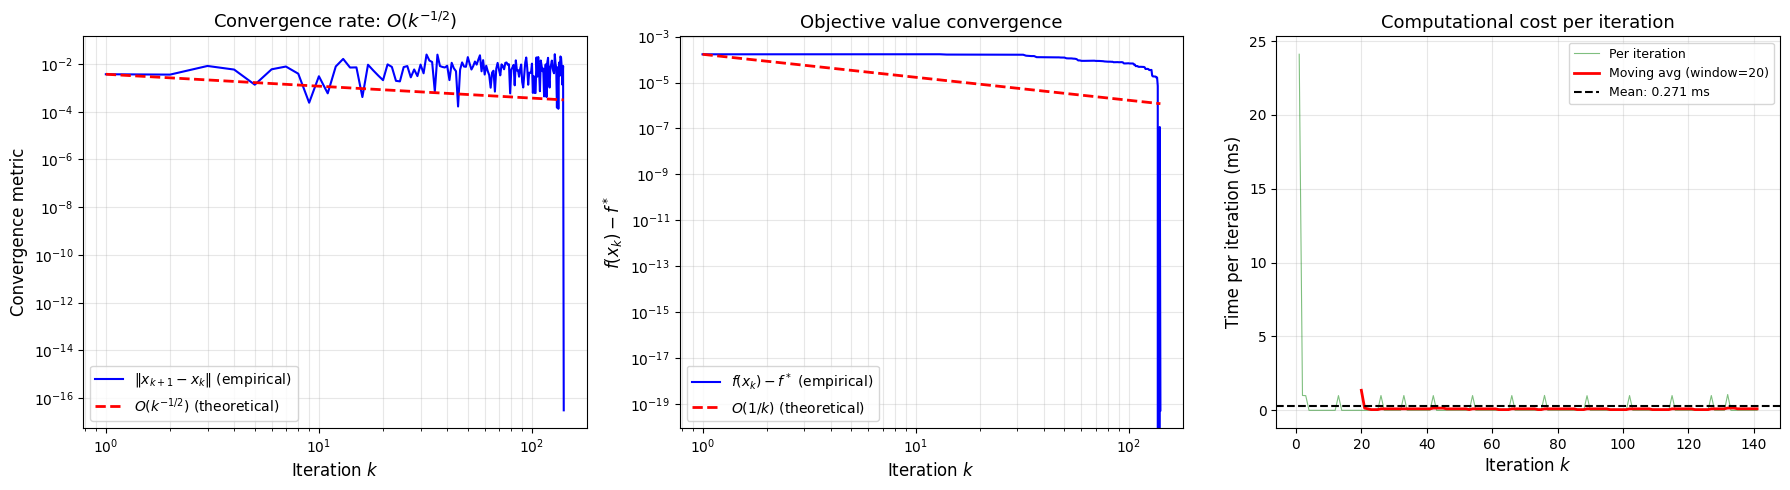

Total time: 0.0382 seconds
Total iterations: 141
Final objective value: -0.000412
Average time per iteration: 0.2708 ms
Std time per iteration: 2.0374 ms


In [18]:
plot_convergence(result_ProjectedGradientDescentMomentum)